Visualisation of the volume and surface area for Legendira

In [19]:
# import
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# load the data
methanobacterium_sa = pd.read_excel(r'20250902_methanobacterium_sa.xls', sheet_name='Sheet1', skiprows=7)
methanobacterium_vol = pd.read_excel(r'20250902_methanobacterium_vol.xls', sheet_name='Sheet1', skiprows=7)
methanosaeata_sa = pd.read_excel(r'20250902_methanosaeata_sa.xls', sheet_name='Sheet1', skiprows=7)
methanosaeata_vol = pd.read_excel(r'20250902_methanosaeata_vol.xls', sheet_name='Sheet1', skiprows=7)
cox_sa = pd.read_excel(r'cox_sa.xls', sheet_name='Sheet1', skiprows=7)
cox_vol = pd.read_excel(r'cox_vol.xls', sheet_name='Sheet1', skiprows=7)
syn_sa = pd.read_excel(r'20250902_syntro_sa.xls', sheet_name='Sheet1', skiprows=7)
syn_vol = pd.read_excel(r'20250902_syntro_vol.xls', sheet_name='Sheet1', skiprows=7)

# remove first row (xyz sub header)
methanobacterium_sa = methanobacterium_sa.iloc[1:]
methanobacterium_vol = methanobacterium_vol.iloc[1:]
methanosaeata_sa = methanosaeata_sa.iloc[1:]
methanosaeata_vol = methanosaeata_vol.iloc[1:]
cox_sa = cox_sa.iloc[1:]
cox_vol = cox_vol.iloc[1:]
syn_sa = syn_sa.iloc[1:]
syn_vol = syn_vol.iloc[1:]

print(methanobacterium_vol.head())

   Index  ObjID                             Filename   Unnamed: 3 Centroid px  \
1    1.0    1.0  legendrea_smol_stack_filter_full.h5   931.812854  668.032136   
2    2.0    2.0  legendrea_smol_stack_filter_full.h5   991.981191  799.937304   
3    3.0    3.0  legendrea_smol_stack_filter_full.h5  1052.006299  700.948031   
4    4.0    4.0  legendrea_smol_stack_filter_full.h5  1127.380746  647.494321   
5    5.0    5.0  legendrea_smol_stack_filter_full.h5  1218.966952  786.935129   

  Unnamed: 5  TimePnt  ObjectId    Volume  Unnamed: 9  Unnamed: 10  \
1   5.483932      1.0       1.0  0.132352         NaN          NaN   
2   5.169279      1.0       2.0  0.039906         NaN          NaN   
3   9.611024      1.0       3.0  0.079436         NaN          NaN   
4  10.765819      1.0       4.0  0.231303         NaN          NaN   
5   5.532436      1.0       5.0  0.102204         NaN          NaN   

   Unnamed: 11  Unnamed: 12  
1          NaN          NaN  
2          NaN          NaN  
3 

In [20]:
# Merge SurfaceArea columns from each DataFrame
surfacearea = methanobacterium_sa[['Index', 'SurfaceArea']].merge(
    cox_sa[['Index', 'SurfaceArea']], on='Index', how='outer', suffixes=('_Methanobacterium', '_Coxiellaceae')
).merge(
    syn_sa[['Index', 'SurfaceArea']], on='Index', how='outer', suffixes=('_Coxiellaceae', '_Syntrophaceae')
).merge(
    methanosaeata_sa[['Index', 'SurfaceArea']], on='Index', how='outer', suffixes=('_Syntrophaceae', '_Methanosaeata')
)

surfacearea.to_excel('surfacearea.xlsx', index=False)

In [21]:
# Merge Volume columns from each DataFrame
vol = methanobacterium_vol[['Index', 'Volume']].merge(
    cox_vol[['Index', 'Volume']], on='Index', how='outer', suffixes=('_Methanobacterium', '_Coxiellaceae')
).merge(
    syn_vol[['Index', 'Volume']], on='Index', how='outer', suffixes=('_Coxiellaceae', '_Syntrophaceae')
).merge(
    methanosaeata_vol[['Index', 'Volume']], on='Index', how='outer', suffixes=('_Syntrophaceae', '_Methanosaeata')
)

vol.to_excel('Volume.xlsx', index=False)

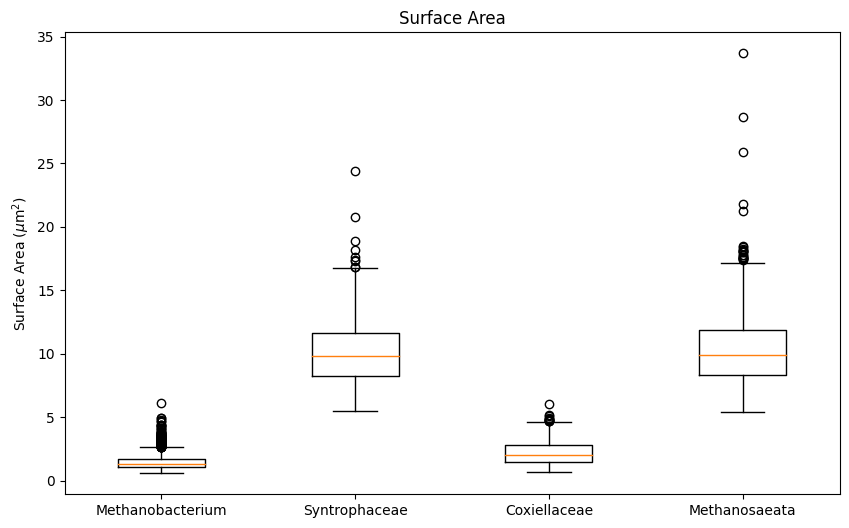

In [22]:
#plot box plot of surface area 
plt.figure(figsize=(10, 6))
plt.boxplot([methanobacterium_sa['SurfaceArea'], syn_sa['SurfaceArea'], cox_sa['SurfaceArea'], methanosaeata_sa['SurfaceArea']],
            labels=['Methanobacterium', 'Syntrophaceae', 'Coxiellaceae', 'Methanosaeata'])
plt.title('Surface Area')
plt.ylabel('Surface Area ($\mu$m$^2$)')
plt.savefig('surface_area_boxplot.svg')
plt.grid(False)
plt.show()

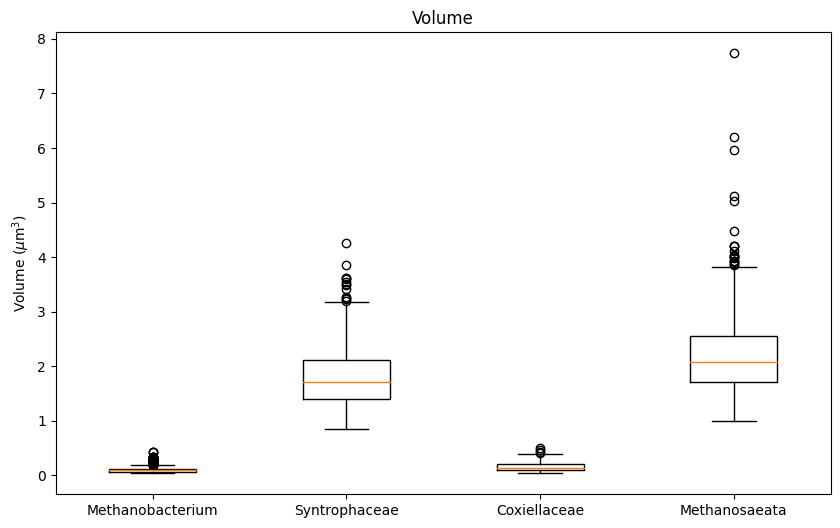

In [23]:
#plot box plot of volume
plt.figure(figsize=(10, 6))
plt.boxplot([methanobacterium_vol['Volume'], syn_vol['Volume'], cox_vol['Volume'], methanosaeata_vol['Volume']],
            labels=['Methanobacterium', 'Syntrophaceae', 'Coxiellaceae', 'Methanosaeata'])
plt.title('Volume')
plt.ylabel('Volume ($\mu$m$^3$)')
plt.savefig('volume_boxplot.svg')
plt.grid(False)
plt.show()

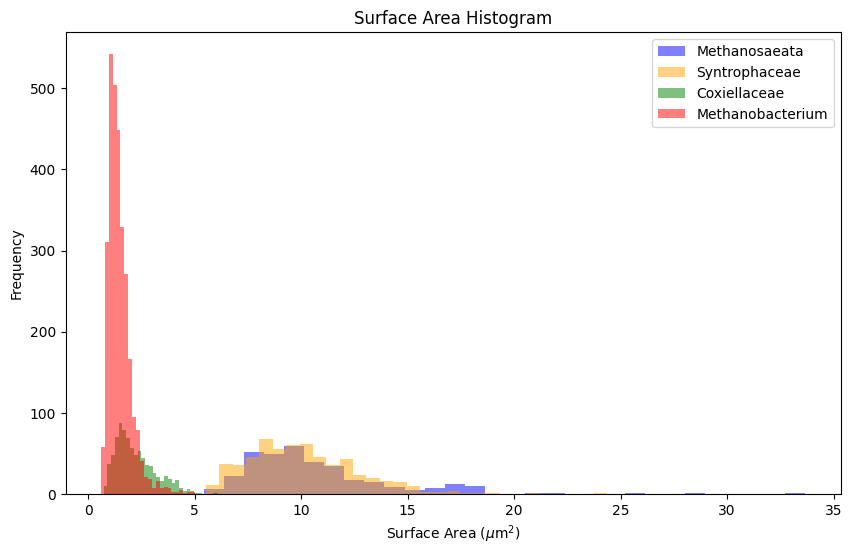

In [24]:
#plot histogram of surface area
plt.figure(figsize=(10, 6))
plt.hist(methanosaeata_sa['SurfaceArea'], bins=30, alpha=0.5, label='Methanosaeata', color='blue')
plt.hist(syn_sa['SurfaceArea'], bins=30, alpha=0.5, label='Syntrophaceae', color='orange')
plt.hist(cox_sa['SurfaceArea'], bins=30, alpha=0.5, label='Coxiellaceae', color='green')
plt.hist(methanobacterium_sa['SurfaceArea'], bins=30, alpha=0.5, label='Methanobacterium', color='red')
plt.title('Surface Area Histogram')
plt.xlabel('Surface Area ($\mu$m$^2$)')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('surface_area_histogram.svg')
plt.show()

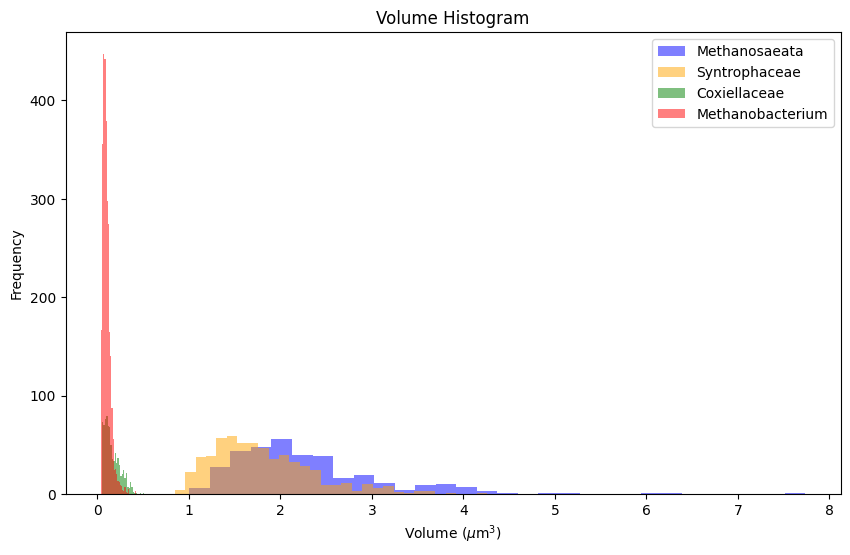

In [25]:
#plot histogram of volume
plt.figure(figsize=(10, 6))
plt.hist(methanosaeata_vol['Volume'], bins=30, alpha=0.5, label='Methanosaeata', color='blue')
plt.hist(syn_vol['Volume'], bins=30, alpha=0.5, label='Syntrophaceae', color='orange')
plt.hist(cox_vol['Volume'], bins=30, alpha=0.5, label='Coxiellaceae', color='green')
plt.hist(methanobacterium_vol['Volume'], bins=30, alpha=0.5, label='Methanobacterium', color='red')
plt.title('Volume Histogram')
plt.xlabel('Volume ($\mu$m$^3$)')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('volume_histogram.svg')
plt.show()